![PowSyBl logo](https://powsybl.readthedocs.io/en/latest/_static/logo_lfe_powsybl.svg)

In [ ]:
%%capture
!pip install pypowsybl

In [ ]:
import pypowsybl as pp
import pandas as pd
from tempfile import TemporaryDirectory
from pathlib import Path
from typing import Any
import json

Copy and paste the following UCTE data in a `network.uct` file that you will use to import the network in pypowsybl.

<details>

<summary>UCTE Network Data</summary>

```uct
##C 2007.05.01
##N
##ZBE
BBE1AA1  BE1          0 2 400.00 0.00000 0.00000 -1000.0 0.00000 9000.00 -9000.0 9000.00 -9000.0
##ZFR
FFR1AA1  FR1          0 2 400.00 1000.00 0.00000 00000.0 0.00000 9000.00 -9000.0 9000.00 -9000.0
FFR2AA1  FR2          0 2 400.00 0000.00 0.00000 00000.0 0.00000 9000.00 -9000.0 9000.00 -9000.0
##L
BBE1AA1  FFR1AA1  1 0 0.0000 10.000 0.000000   700
BBE1AA1  FFR1AA1  2 0 0.0000 10.000 0.000000   1000
BBE1AA1  FFR1AA1  3 8 0.0000 10.000 0.000000   1000
FFR2AA1  FFR1AA1  1 0 0.0000 5.0000 0.000000   400
##T
BBE1AA1  FFR2AA1  1 0 400.0 400.0 1000. 0.0000 5.0000 0.000000 0.0	     1000 PST
##R
BBE1AA1  FFR2AA1  1                    -0.68 90.00 16 0         SYMM
```

</details>

# Study of the network

In [ ]:
network = pp.network.load("network.uct")

## Utility methods

Below are some utility methods that will be helpful to study the network.

In [ ]:
def get_current(branch: str, n: pp.network.Network) -> float:
    return n.get_branches(True).loc[branch].i1

In [ ]:
def get_patl(branch: str, n: pp.network.Network) -> float:
    operational_limits = n.get_operational_limits().loc[branch]
    patls = operational_limits[operational_limits.name == "permanent_limit"]
    return patls.value.min()

In [ ]:
def compute_loading(branch: str, n: pp.network.Network) -> float:
    return round(100 * get_current(branch, n) / get_patl(branch, n), 2)

In [ ]:
def study_branch(branch: str, n: pp.network.Network) -> None:
    print(f"Current on {branch}: {get_current(branch, n)} A ({compute_loading(branch, n)}% loading)")

In [ ]:
def get_pst_tap_positions(pst: str, n: pp.network.Network) -> list[int]:
    return list(n.get_phase_tap_changer_steps().loc[pst].index)

In [ ]:
def simulate_pst_action(pst: str, monitored_line: str, n: pp.network.Network) -> pd.DataFrame:
    pst_action_results = []
    initial_tap = n.get_phase_tap_changers().loc[pst].tap

    for tap_position in sorted(get_pst_tap_positions(pst, n)):
        n.update_phase_tap_changers(id=pst, tap=tap_position)
        pp.loadflow.run_ac(n)
        pst_action_results.append(
            {
                "tap_position": tap_position,
                "current": get_current(monitored_line, n),
                "loading": compute_loading(monitored_line, n),
                "margin": get_patl(monitored_line, n) - get_current(monitored_line, n)
            }
        )

    df = pd.DataFrame(pst_action_results)
    df.set_index("tap_position", inplace=True)

    n.update_phase_tap_changers(id=pst, tap=initial_tap)  # reset tap position

    return df

## Basecase

Let's study the network in the basecase. Let's run an AC loadflow and have a look at the flows on the different branches of the network.

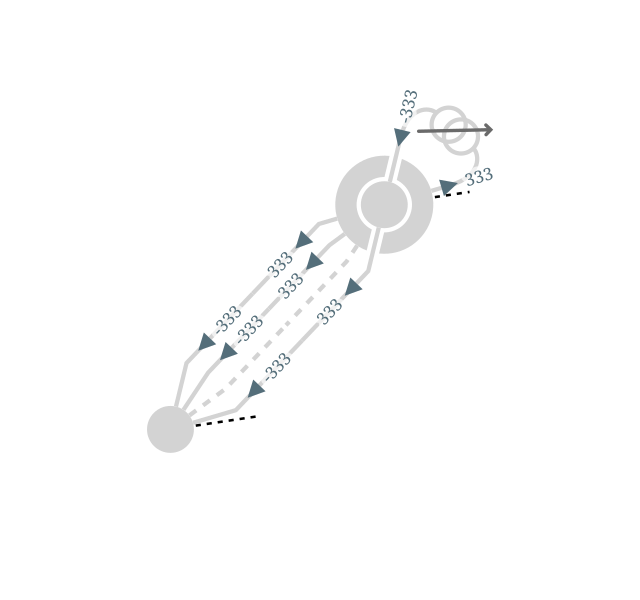

In [ ]:
pp.loadflow.run_ac(network)
network.get_network_area_diagram()

The line _FFR2AA1  FFR1AA1  1_ is highlighted meaning that there is an overload.

In [ ]:
study_branch("FFR2AA1  FFR1AA1  1", network)

Current on FFR2AA1  FFR1AA1  1: 481.1481762780628 A (120.29% loading)


Indeed, there is a **20.29% overload** on the branch. Let us manually apply remedial actions to try to solve the constraint.

### Manual activation of the PST

First, let's keep the network topology as it is and simply change the tap position of the PST (_BBE1AA1  FFR2AA1  1_) to see how the flow on the critical branch is impacted.

> We can use the `simulate_pst_action` utility method that automatically tests all possible taps and runs an AC loadflow on the network to compute the loading on the critical branch.

In [ ]:
df = simulate_pst_action("BBE1AA1  FFR2AA1  1", "FFR2AA1  FFR1AA1  1", network)
df[df.loading <= 100] # only study secure tap positions

,current,loading,margin
tap_position,,,
1,376.463657,94.12,23.536343
2,271.783421,67.95,128.216579
3,167.110008,41.78,232.889992
4,62.445957,15.61,337.554043
5,42.206194,10.55,357.793806
6,146.843911,36.71,253.156089
7,251.464658,62.87,148.535342
8,356.065906,89.02,43.934094


Initially, the PST is on tap position 0. From the previous study, it is sufficient to move the tap by only one step to **tap position 1** to secure the critical branch (with a 94.12% loading).

Note that the **tap position 5** offers the maximum margin value on the critical branch with a very low loading (only 10.55%).

To sum up:
- tap position 1 is the first secure tap position and can be used to secure the network by changing the network as few as possible. *It is the tap position that should be selected during a Coordinated Security Analysis (CSA).*
- tap position 5 is the tap position that allows the greatest margin on the critical branch. *It is the tap position that should be selected during a flow-based Capacity Calculation (CC).*

### Manual activation of the topological action

We also have the possibility to close the line _BBE1AA1  FFR1AA1  3_. Let's see how the flows are impacted.

In [ ]:
network.connect("BBE1AA1  FFR1AA1  3")

True

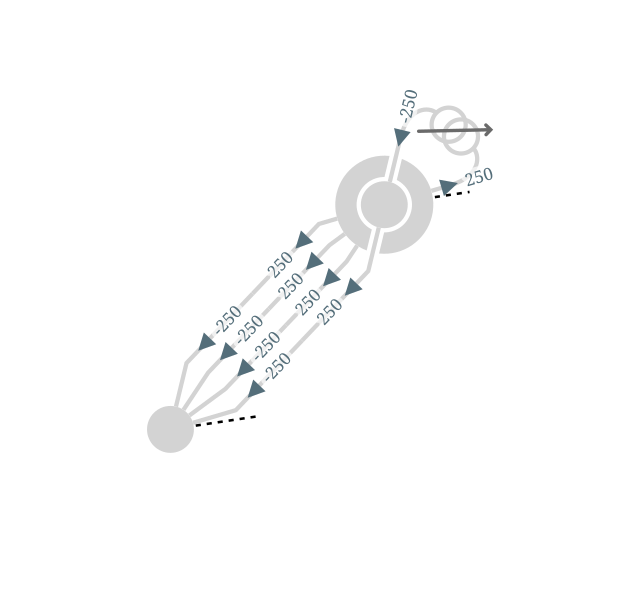

In [ ]:
pp.loadflow.run_ac(network)
network.get_network_area_diagram()

In [ ]:
study_branch("FFR2AA1  FFR1AA1  1", network)

Current on FFR2AA1  FFR1AA1  1: 360.85448373298385 A (90.21% loading)


The overload is solved! Let's add the PST remedial action to see how much margin we can save.

In [ ]:
df = simulate_pst_action("BBE1AA1  FFR2AA1  1", "FFR2AA1  FFR1AA1  1", network)
df[df.loading <= 100] # only study secure tap positions

,current,loading,margin
tap_position,,,
0,360.854484,90.21,39.145516
1,243.079432,60.77,156.920568
2,125.307878,31.33,274.692122
3,7.542622,1.89,392.457378
4,110.213540,27.55,289.786460
5,227.957812,56.99,172.042188
6,345.687401,86.42,54.312599


By moving the PST to tap position 3, we can maximize the margin on the critical element by reaching a loading of only 1.89%. This is what we would expect from the RAO in the context of a flow-based CC process.

In a nutshell:
- for a CSA, we expect the RAO to secure the network by simply moving the PST to tap position 1
- for a flow-based CC, we expect the RAO to use the topological action to close line _BBE1AA1  FFR1AA1  3_ and to move the PST to tap position 3

We will check this later. For now, let's move on with our study of the network by simulating a contingency on line _BBE1AA1  FFR1AA1  2_.

## N-1 contingency scenario

Let's re-import the network to reset it and the simulate the loss of line _BBE1AA1  FFR1AA1  2_.

In [ ]:
network = pp.network.load("network.uct")
network.disconnect("BBE1AA1  FFR1AA1  2")

True

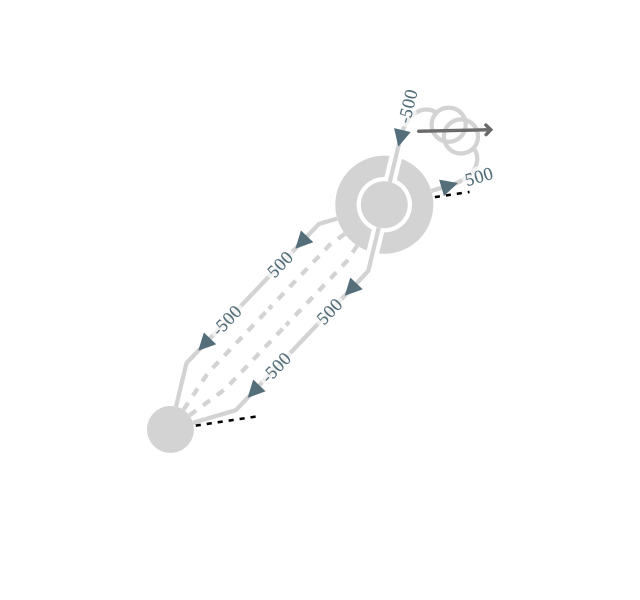

In [ ]:
pp.loadflow.run_ac(network)
network.get_network_area_diagram()

In [ ]:
study_branch("BBE1AA1  FFR1AA1  1", network)
study_branch("FFR2AA1  FFR1AA1  1", network)

Current on BBE1AA1  FFR1AA1  1: 721.7291448073529 A (103.1% loading)
Current on FFR2AA1  FFR1AA1  1: 721.7511751078374 A (180.44% loading)


Now we have two overloaded lines. Let's assume that for some reasons, the topological action is not available in curative so we can only rely on the PST. Let's see how it can help solve the constraints.

In [ ]:
df = simulate_pst_action("BBE1AA1  FFR2AA1  1", "BBE1AA1  FFR1AA1  1", network)
df[df.loading <= 100] # only study secure tap positions

,current,loading,margin
tap_position,,,
-16,533.114894,76.16,166.885106
-15,454.840465,64.98,245.159535
-14,376.537743,53.79,323.462257
-13,298.208401,42.60,401.791599
-12,219.854115,31.41,480.145885
-11,141.476562,20.21,558.523438
-10,63.077425,9.01,636.922575
-9,15.341611,2.19,684.658389
-8,93.778858,13.40,606.221142


In [ ]:
df = simulate_pst_action("BBE1AA1  FFR2AA1  1", "FFR2AA1  FFR1AA1  1", network)
df[df.loading <= 100] # only study secure tap positions

,current,loading,margin
tap_position,,,
5,329.337487,82.33,70.662513
6,250.892355,62.72,149.107645
7,172.464851,43.12,227.535149
8,94.057153,23.51,305.942847
9,15.671436,3.92,384.328564
10,62.671410,15.67,337.328590
11,141.003091,35.25,258.996909
12,219.305820,54.83,180.694180
13,297.577407,74.39,102.422593


The situation is unsolvable. Line _BBE1AA1  FFR1AA1  1_ can be secured for any tap position in the range from -16 to -1, whereas line _FFR2AA1  FFR1AA1  1_ can be secured for any tap position in the range from 5 to 14.

What if we had activated the topological action in preventive?

In [ ]:
network.connect("BBE1AA1  FFR1AA1  3")

True

In [ ]:
df = simulate_pst_action("BBE1AA1  FFR2AA1  1", "BBE1AA1  FFR1AA1  1", network)
df[df.loading <= 100] # only study secure tap positions

,current,loading,margin
tap_position,,,
-16,355.349728,50.76,344.650272
-15,303.180334,43.31,396.819666
-14,250.990243,35.86,449.009757
-13,198.780702,28.40,501.219298
-12,146.552959,20.94,553.447041
-11,94.308268,13.47,605.691732
-10,42.047882,6.01,657.952118
-9,10.226942,1.46,689.773058
-8,62.514943,8.93,637.485057


In [ ]:
df = simulate_pst_action("BBE1AA1  FFR2AA1  1", "FFR2AA1  FFR1AA1  1", network)
df[df.loading <= 100] # only study secure tap positions

,current,loading,margin
tap_position,,,
1,376.463657,94.12,23.536343
2,271.783421,67.95,128.216579
3,167.110008,41.78,232.889992
4,62.445957,15.61,337.554043
5,42.206194,10.55,357.793806
6,146.843911,36.71,253.156089
7,251.464658,62.87,148.535342
8,356.065906,89.02,43.934094


We now have an overlap between secure tap positions for each branch. With the preventive topological action applied, any tap position between 1 and 4 solves both constraints at once.

Let's have a look at the margins (respectively for _BBE1AA1  FFR1AA1  1_ and _FFR2AA1  FFR1AA1  1_) for these secure tap positions:
1. 166.51 A and 23.53 A (worst margin: 23.53 A)
2. 114.16 A and 128.22 A (worst margin: 114.16 A)
3. 61.81 A and 222.89 A (worst margin: 61.81 A)
4. 9.46 A and 337.56 A (worst margin: 9.36 A)

Among all these situations, tap position 2 is the one for which the worst margin is highest, and it should be selected by the RAO. Let's verify this!

# Practice

Now is your turn to work. You will configure and run a full RAO using pypowsybl to verify the observations of the study above. You can find 4 different exercices below to perform a basecase and N-1 optimizations for both CSA and flow-based CC processes.

> 💡 You can check the [OpenRAO documentation](https://powsybl.readthedocs.io/projects/openrao/en/stable/index.html) if you need help.

First of all, let's activate the OpenRAO logs to better study the behavior of the RAO.

In [ ]:
logging.basicConfig(format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger("powsybl")
logger.setLevel(logging.INFO)
logger.addFilter(pp.rao.RaoLogFilter())

## **Exercice 1:** Run a basecase CSA RAO

In this first exercice, we will validate our observations on the basecase remedial actions by running OpenRAO using a CSA configuration. The RAO should thus stop as soon as it manages to secure the network.

1. **Create RAO parameters for CSA**

You will need a configuration file to run the RAO. Copy the content of the JSON code snippet below to a `rao-parameters-csa.json` file and fill in the `...` with the appropriate objective function type.

<details>

<summary>JSON RAO Parameters Template</summary>

```json
{
  "version": "3.3",
  "objective-function": {
    "type": ...,
    "enforce-curative-security": false
  },
  "extensions": {
    "open-rao-search-tree-parameters": {
      "objective-function": {
        "curative-min-obj-improvement": 10000.0
      },
      "range-actions-optimization": {
        "max-mip-iterations": 10,
        "pst-sensitivity-threshold": 1.0E-6,
        "pst-model": "APPROXIMATED_INTEGERS",
        "hvdc-sensitivity-threshold": 1.0E-6,
        "injection-ra-sensitivity-threshold": 1.0E-6,
        "linear-optimization-solver": {
          "solver": "CBC",
          "relative-mip-gap": 1.0E-4,
          "solver-specific-parameters": null
        }
      },
      "load-flow-and-sensitivity-computation": {
        "load-flow-provider": "OpenLoadFlow",
        "sensitivity-provider": "OpenLoadFlow",
        "sensitivity-failure-overcost": 10000.0,
        "sensitivity-parameters": {
          "version": "1.0",
          "load-flow-parameters": {
            "version": "1.10",
            "voltageInitMode": "UNIFORM_VALUES",
            "transformerVoltageControlOn": false,
            "phaseShifterRegulationOn": false,
            "useReactiveLimits": true,
            "twtSplitShuntAdmittance": false,
            "shuntCompensatorVoltageControlOn": false,
            "readSlackBus": true,
            "writeSlackBus": true,
            "dc": false,
            "distributedSlack": true,
            "balanceType": "PROPORTIONAL_TO_GENERATION_P",
            "dcUseTransformerRatio": true,
            "countriesToBalance": [],
            "componentMode": "MAIN_CONNECTED",
            "hvdcAcEmulation": true
          }
        }
      }
    }
  }
}
```

</details>

Then, import the configuration file.

In [ ]:
# TODO: rao_parameters_csa = ...

2. **Create a CRAC containing one preventive CNEC on the line _FFR2AA1  FFR1AA1  1_, a PST range action and a topological action**

To run the RAO we need all the data regarding the critical branch and the remedial actions to be gathered in a CRAC file. Create a JSON CRAC file `crac-basecase.json` that contains:
- one preventive FlowCNEC defined on line _FFR2AA1  FFR1AA1  1_ with a 400 A threshold (PATL)
- one *free-to-use* preventive PST range action defined on PST _BBE1AA1  FFR2AA1  1_
- one *free-to-use* topological remedial action that closes line _BBE1AA1  FFR1AA1  3_

> 💡 You can check the [JSON CRAC format page](https://powsybl.readthedocs.io/projects/openrao/en/stable/input-data/crac/json.html) on the OpenRAO documentation for help.


You can then import the CRAC.

In [ ]:
# TODO: crac = ...

3. **Run RAO and retrieve RAO result**

Use the RAO Parameters and the CRAC you created to run OpenRAO and retrieve the RAO Result. First, import the network in a new variable as the RAO will alter the state of the netork.

In [ ]:
rao_network = pp.network.load("network.uct")

Then create the RAO engine.

In [ ]:
# TODO: rao = ...

Finally, run the RAO computation and store the RAO result in a variable that we will study afterwards.

In [ ]:
# TODO: rao_result = ...

4. **Check the optimal remedial actions**

Now that the RAO successfully ran, let's see which remedial actions it chose to apply. First, let's ensure that the topological action was not activated.

In [ ]:
# TODO: rao_result...

The empty dataframe means that no topological action was indeed activated. This is because the PST alone is sufficient to secure the network so the search-tree algorithm in CASTOR stops at the root leaf.

Then, let's make sure that the PST remedial action was indeed activated.

In [ ]:
# TODO: rao_result...

Wait... the PST range action is indeed activated but we were expecting the RAO to select tap position 1 as it is the first secure tap position, but instead we got tap position 5! Is this a bug?

Actually it is not. The linear model solver that is used in CASTOR to find the optimal taps of the PSTs always tries to maximize the minimum margin in its current implementation. This is why tap position 5 is chosen.

The RAO behaved as exepected. Now let's have a look at what happens using a flow-based CC configuration.

## **Exercice 2:** Run a basecase flow-based CC RAO

This second exercice, is very similar to the previous one except now we will configure the RAO to run in a flow-based CC mode.

1. **Create RAO parameters for flow-based CC**

Copy and paste the same JSON RAO parameters code snippet in a `rao-parameters-cc.json` file and fill in the `...` with the right objective function type.

Then, import the configuration file.

In [ ]:
# TODO: rao_parameters_cc = ...

2. **Run RAO and retrieve RAO result**

We can reuse the same CRAC as in the first exercice. Using the flow-based CC configuration, let's run another RAO. Once again, do not forget to re-import the network to start from the original data.

In [ ]:
rao_network = pp.network.load("network.uct")

In [ ]:
# TODO: rao = ...

In [ ]:
# TODO: rao_result = ...

3. **Check the optimal remedial actions**

Let's have a look at the activated remedial actions, starting with the topological action.

In [ ]:
# TODO: rao_result...

We can see that the topological action was indeed selected in preventive.

Now let's ensure that the PST tap position was also changed by the RAO during the optimization.

In [ ]:
# TODO: rao_result...

As expected, the RAO set the PST on tap position 3 as this is the tap position that, when combined with the topological action, maximizes the margin on the CNEC. The RAO did perfom as we planned for the basecase optimization!

It is now time to include the N-1 optimization in the RAO process to see how it behaves when considering contingencies and curative optimization.

## **Exercice 3:** Run a complete (basecase + N-1) flow-based CC RAO

First, let's stick to the flow-based CC configuration and indicate the RAO that it should simulate the contingency.

1. **Create a new CRAC based on the basecase one with curative optimization data**

First, let's update our CRAC with the data required for the curative optimization. We shall add:
- a curative instant
- a curative FlowCNEC on line _FFR2AA1  FFR1AA1  1_
- a curative usage rule to the PST

Besides, we saw during our study that the line _BBE1AA1  FFR1AA1  1_ got overloaded because of the contingency. It is worth defining a curative FlowCNEC on this line too.

Save the JSON data in a `crac-n-1.json` file and import it.

In [ ]:
# TODO: crac = ...

2. **Run RAO and retrieve RAO result**

Run the RAO once again and extract the RAO Result. This time it should contain both preventive and curative results.

In [ ]:
rao_network = pp.network.load("network.uct")

In [ ]:
# TODO: rao = ...

In [ ]:
# TODO: rao_result = ...

3. **Check the optimal remedial actions**

As previously, let's have a look at the activated remedial actions, starting with the topological action.

In [ ]:
# TODO: rao_result...

As expected, the topological action is activated by the RAO in preventive.

Now let's have a look at the activation of the PST range action.

In [ ]:
# TODO: rao_result...

Here again the RAO behaved as expected. The PST is activated twice:
- first during the preventive optimization when its tap is set on position 3 as it maximizes the preventive margin
- then during the curative optimization when it is moved to tap position 2 to maximize the curative margin

Let's finish by running a full RAO (basecase and N-1) with a CSA configuration.

## **Exercice 4:** Run a complete (basecase + N-1) CSA RAO

1. **Run RAO and retrieve RAO result**

We already have all the required data to run a full CSA RAO.

In [ ]:
rao_network = pp.network.load("network.uct")

In [ ]:
# TODO: rao = ...

In [ ]:
# TODO: rao_result = ...

2. **Check the optimal remedial actions**

Let's check which remedial actions the RAO chose to activate, starting with the topological action.

In [ ]:
# TODO: rao_result...

The topological action was not activated. This means that the RAO could not secure the network. This can be checked by looking at the curative functional cost.

In [ ]:
# TODO: rao_result...

Indeed, the functional cost of the RAO after the preventive and curative optimizations is 148, which means that the most limiting FlowCNEC has a 148 A overload.

This happened because the preventive optimization was not greedy enough. Indeed, during the preventive optimization, the PST alone is sufficient to secure the network so the RAO does not need to apply the topological remedial action. However, as we saw during the study of the N-1 case, it is impossible to secure all FlowCNECs in curative without the topological action.

This is where the **second preventive optimization** is useful. The RAO will re-optimize the preventive topological remedial actions and all the PST range actions (preventive and curative) at once being aware of all the FlowCNECs.

Thus, instead on only *seeing* the preventive FlowCNEC, the preventive optimization will be aware of all three FlowCNECs defined in the CRAC and adapt its remedial action selection in consequence.

Let's run the RAO again with the second preventive optimization activated.

3. **Activate second preventive optimization in the configuration**

Copy and paste the content of `rao-parameters-csa.json` in a new file called `rao-parameters-csa-2P.json`. In the latter, add the second preventive optimization parameters extension and import the parameters.

In [ ]:
# TODO: rao_parameters_2P = ...

4. **Run RAO with second preventive optimization and retrieve RAO result**

Let's run the RAO with the updated configuration.

In [ ]:
rao_network = pp.network.load("network.uct")

In [ ]:
# TODO: rao = ...

In [ ]:
# TODO: rao_result = ...

5. **Check the optimal remedial actions**

Let's ensure that the topological action was activated this time.

In [ ]:
# TODO: rao_result

Thanks to the second preventive optimization, the topological action is properly activated. But what about the PST?

Though we can expect the RAO to set the curative tap position to 2 as this is the one maximizing the worst curative margin, are you able to predict which is the optimal preventive tap?

In [ ]:
# TODO: rao_result

The optimal curative tap position is indeed 2 but interestingly, the PST remedial action was not activated in preventive.

The reason is that during the global search-tree optimization, when the topological action is applied and the leaf evaluated, the search-tree sees that the stop criterion is already reached so no further optimization is required. As the curative remedial actions are already applied by default, the optimization exits early without the preventive PST being optimized.